In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
dataset_path="/kaggle/input/datasets/drgfreeman/rockpaperscissors"
print(dataset_path)

/kaggle/input/datasets/drgfreeman/rockpaperscissors


In [3]:
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    print(f"{subindent}{len(files)} files")

rockpaperscissors/
    1 files
    paper/
        712 files
    rock/
        726 files
    rps-cv-images/
        1 files
        paper/
            712 files
        rock/
            726 files
        scissors/
            750 files
    scissors/
        750 files


In [4]:
import os
import numpy as np
from PIL import Image

dataset_path 

data = []

for label in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, label)

    if os.path.isdir(folder_path):

        for image_name in os.listdir(folder_path):
            image_path = os.path.join(folder_path, image_name)

            try:
                image = Image.open(image_path).convert("RGB")
                image = np.array(image)
                
                data.append((image, label))

            except:
                pass

In [5]:
X = np.array([item[0] for item in data])
y = np.array([item[1] for item in data])

print(X.shape)
print(y.shape)
print(y[:10])

(2188, 200, 300, 3)
(2188,)
['paper' 'paper' 'paper' 'paper' 'paper' 'paper' 'paper' 'paper' 'paper'
 'paper']


In [6]:
print(type(X))
print(X.dtype)
print(X.shape)

print("First image:", type(X[0]))

<class 'numpy.ndarray'>
uint8
(2188, 200, 300, 3)
First image: <class 'numpy.ndarray'>


In [7]:
print(X.dtype)
print(X.shape)
print(X[0].dtype)
print(X[0].shape)

uint8
(2188, 200, 300, 3)
uint8
(200, 300, 3)


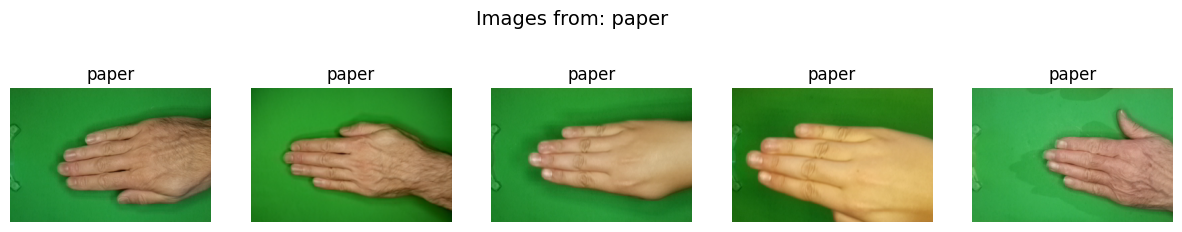

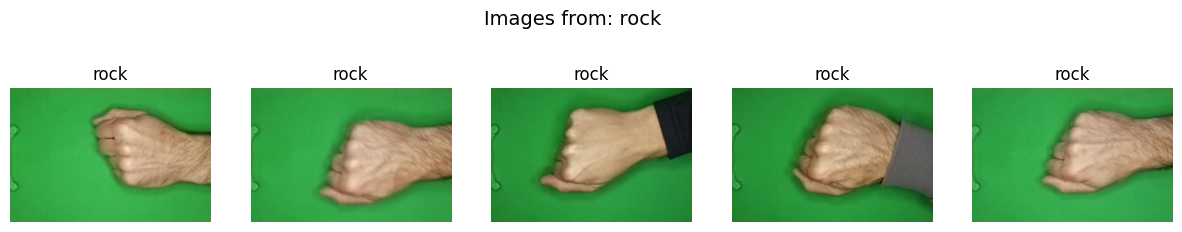

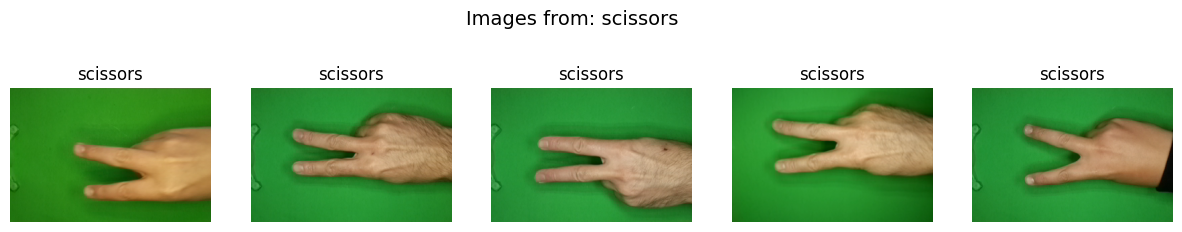

In [8]:
import matplotlib.pyplot as plt
import numpy as np

unique_labels = np.unique(y)

for label in unique_labels:

    # Find indexes of images belonging to this label
    indexes = np.where(y == label)[0]

    # Take first 5 images
    indexes = indexes[:5]

    plt.figure(figsize=(15, 3))

    for i, index in enumerate(indexes):

        plt.subplot(1, 5, i + 1)

        plt.imshow(X[index])
        plt.title(label)
        plt.axis("off")

    plt.suptitle(f"Images from: {label}", fontsize=14)
    plt.show()

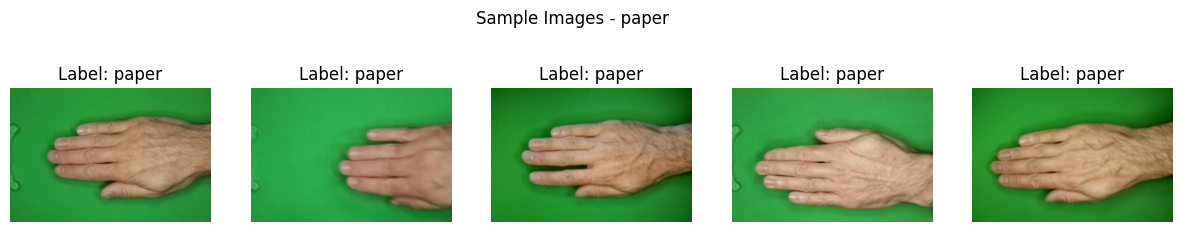

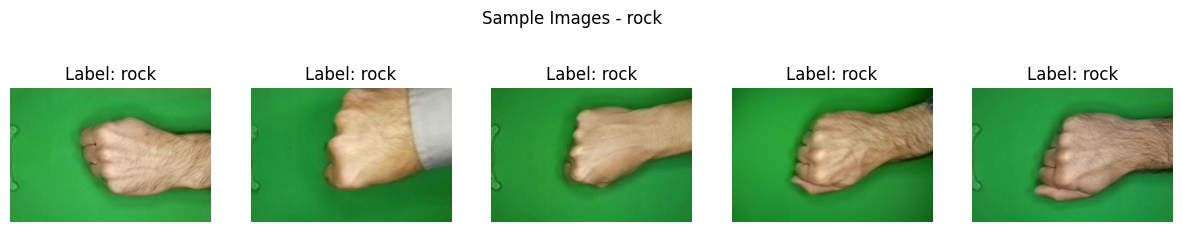

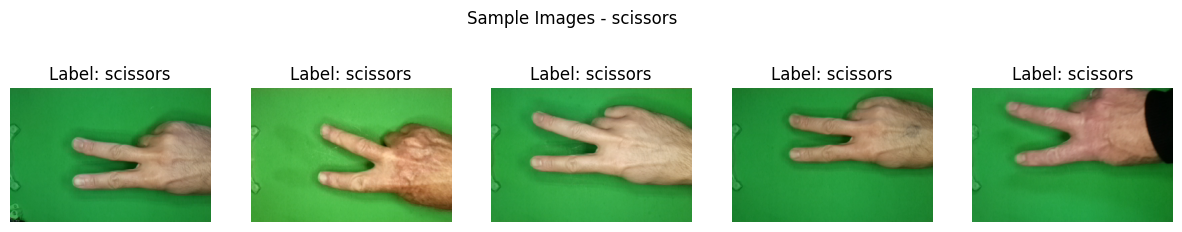

In [9]:
import matplotlib.pyplot as plt
import numpy as np

unique_labels = np.unique(y)

for label in unique_labels:

    indexes = np.where(y == label)[0]

    # Randomly select 5 images
    selected = np.random.choice(
        indexes,
        size=min(5, len(indexes)),
        replace=False
    )

    plt.figure(figsize=(15, 3))

    for i, index in enumerate(selected):

        plt.subplot(1, 5, i + 1)

        plt.imshow(X[index])
        plt.title(f"Label: {y[index]}")
        plt.axis("off")

    plt.suptitle(f"Sample Images - {label}")
    plt.show()

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

In [11]:
augmented_images = []
augmented_labels = []

for image, label in zip(X, y):

    image_batch = np.expand_dims(image, axis=0)

    aug_iterator = datagen.flow(
        image_batch,
        batch_size=1,
        shuffle=False
    )

    augmented_image = next(aug_iterator)[0]

    augmented_images.append(augmented_image)
    augmented_labels.append(label)   # already 0, 1, or 2

augmented_images = np.array(augmented_images)
augmented_labels = np.array(augmented_labels)

In [12]:
augmented_images = np.array(augmented_images)
augmented_labels = np.array(augmented_labels)

In [13]:
print("Original images:", X.shape)
print("Augmented images:", augmented_images.shape)

print("Original labels:", y.shape)
print("Augmented labels:", augmented_labels.shape)

Original images: (2188, 200, 300, 3)
Augmented images: (2188, 200, 300, 3)
Original labels: (2188,)
Augmented labels: (2188,)


In [14]:
print(augmented_labels[:10])

['paper' 'paper' 'paper' 'paper' 'paper' 'paper' 'paper' 'paper' 'paper'
 'paper']


In [15]:
X_augmented = np.concatenate(
    [X, augmented_images],
    axis=0
)

y_augmented = np.concatenate(
    [y, augmented_labels],
    axis=0
)

In [16]:
print(X_augmented.shape)
print(y_augmented.shape)

(4376, 200, 300, 3)
(4376,)


In [17]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y_augmented)

print(y_encoded[:10])
print(encoder.classes_)

[0 0 0 0 0 0 0 0 0 0]
['paper' 'rock' 'scissors']


In [18]:
for i, class_name in enumerate(encoder.classes_):
    print(i, "→", class_name)

0 → paper
1 → rock
2 → scissors


In [20]:
unique, counts = np.unique(y_encoded, return_counts=True)

for label, count in zip(unique, counts):
    print(f"{label} → {y_encoded[label]} : {count} images")

0 → 0 : 1424 images
1 → 0 : 1452 images
2 → 0 : 1500 images


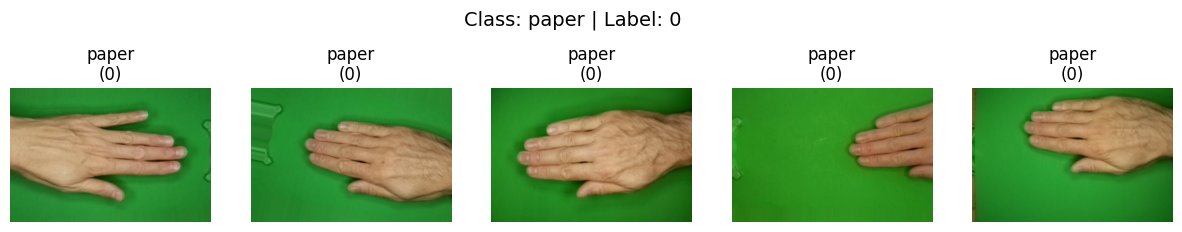

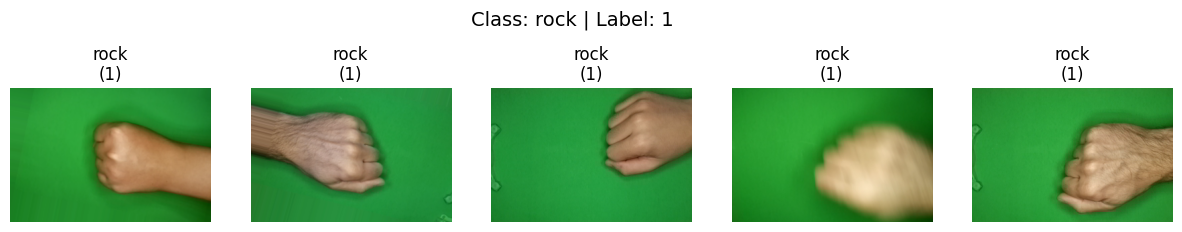

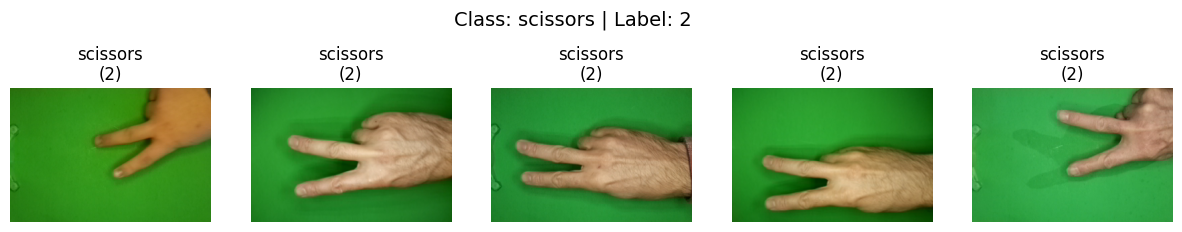

In [21]:
import matplotlib.pyplot as plt
import numpy as np

label_names = {
    0: "paper",
    1: "rock",
    2: "scissors"
}

for label in [0, 1, 2]:

    # Find images belonging to this class
    indexes = np.where(y_encoded == label)[0]

    # Select 5 random images
    selected = np.random.choice(
        indexes,
        size=min(5, len(indexes)),
        replace=False
    )

    plt.figure(figsize=(15, 3))

    for i, index in enumerate(selected):

        plt.subplot(1, 5, i + 1)

        plt.imshow(X_augmented[index].astype("uint8"))

        plt.title(f"{label_names[label]}\n({label})")
        plt.axis("off")

    plt.suptitle(
        f"Class: {label_names[label]} | Label: {label}",
        fontsize=14
    )

    plt.show()

In [22]:
print("X_augmented shape:", X_augmented.shape)
print("X_augmented dtype:", X_augmented.dtype)

X_augmented shape: (4376, 200, 300, 3)
X_augmented dtype: float32


In [23]:
for i in range(10):
    print(f"Image {i}: {X_augmented[i].shape}")

Image 0: (200, 300, 3)
Image 1: (200, 300, 3)
Image 2: (200, 300, 3)
Image 3: (200, 300, 3)
Image 4: (200, 300, 3)
Image 5: (200, 300, 3)
Image 6: (200, 300, 3)
Image 7: (200, 300, 3)
Image 8: (200, 300, 3)
Image 9: (200, 300, 3)


In [24]:
unique_shapes = set(image.shape for image in X_augmented)

print("Different image shapes:")
for shape in unique_shapes:
    print(shape)

print("Number of different shapes:", len(unique_shapes))

Different image shapes:
(200, 300, 3)
Number of different shapes: 1


In [25]:
import numpy as np
import cv2

target_size = (224, 224)  # (width, height)

# images: your existing array, shape (N, 200, 300, 3)
resized_images = np.array([
    cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    for img in X_augmented
])

images = resized_images  # overwrite the same variable
print(images.shape)  # (N, 224, 224, 3)

(4376, 224, 224, 3)


In [26]:
import cv2
import numpy as np

# Assuming you still have the resized (but not yet normalized) images
images_gray = [cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in resized_images]  # or RGB2GRAY
images_gray = np.array(images_gray)[..., np.newaxis]  # add channel dim -> (N,224,224,1)

# Normalize now, after grayscale conversion
images_gray = images_gray.astype(np.float32) / 255.0

In [54]:
# import numpy as np

# images = np.array(images, dtype=np.float32) / 255.0  # scale to [0,1]

In [27]:
from sklearn.model_selection import train_test_split

# Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    images_gray,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

# Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [28]:
print("Training Images   :", X_train.shape)
print("Validation Images :", X_val.shape)
print("Testing Images    :", X_test.shape)

print()

print("Training Labels   :", y_train.shape)
print("Validation Labels :", y_val.shape)
print("Testing Labels    :", y_test.shape)

Training Images   : (3063, 224, 224, 1)
Validation Images : (656, 224, 224, 1)
Testing Images    : (657, 224, 224, 1)

Training Labels   : (3063,)
Validation Labels : (656,)
Testing Labels    : (657,)


In [30]:
print("Training Set")
print(np.unique(y_train, return_counts=True))

print()

print("Validation Set")
print(np.unique(y_val, return_counts=True))

print()

print("Testing Set")
print(np.unique(y_test, return_counts=True))

Training Set
(array([0, 1, 2]), array([ 997, 1016, 1050]))

Validation Set
(array([0, 1, 2]), array([213, 218, 225]))

Testing Set
(array([0, 1, 2]), array([214, 218, 225]))


In [59]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D,Flatten
)
from tensorflow.keras.layers import Input

In [60]:
model = Sequential([

    # First Convolution Block
    Input(shape=(224,224,1)),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    # Second Convolution Block
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    # Third Convolution Block
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    # Convert Feature Maps into a Vector
    # GlobalAveragePooling2D(), 
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    # Output Layer
    Dense(3, activation='softmax')
])

In [61]:
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,755 (49.36 MB)

 Trainable params: 12,938,499 (49.36 MB)

 Non-trainable params: 256 (1.00 KB)

In [62]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # if labels are integers 0,1,2
    # loss='categorical_crossentropy',       # if labels are one-hot [1,0,0] etc.
    metrics=['accuracy']
)

In [63]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 93ms/step - accuracy: 0.6879 - loss: 0.7633 - val_accuracy: 0.3247 - val_loss: 6.9193
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.8812 - loss: 0.3498 - val_accuracy: 0.8354 - val_loss: 0.4643
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.9226 - loss: 0.2476 - val_accuracy: 0.7393 - val_loss: 0.5772
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.9500 - loss: 0.1683 - val_accuracy: 0.3628 - val_loss: 2.3000
Epoch 5/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.9651 - loss: 0.1357 - val_accuracy: 0.3247 - val_loss: 8.6735
Epoch 6/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.9618 - loss: 0.1378 - val_accuracy: 0.9116 - val_loss: 0.2567
Epoch 7/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.9719 - loss: 0.0999 - val_accuracy: 0.3354 - val_loss: 4.5985
Epoch 8/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.9745 - loss: 0.0866 - val_accuracy: 0.7713 - 

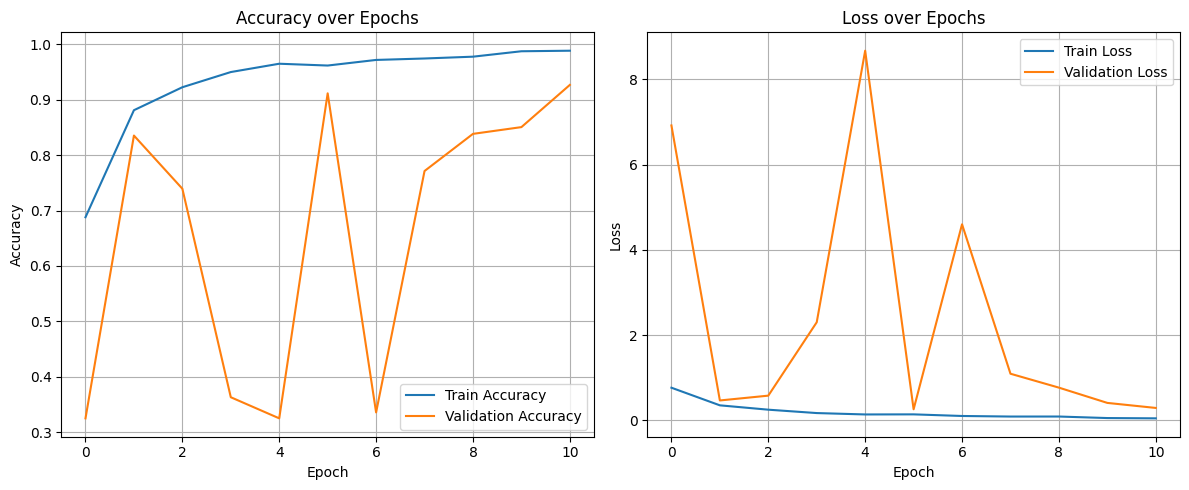

In [64]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [65]:
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
gap = final_train_acc - final_val_acc

print(f"Train Accuracy: {final_train_acc:.4f}")
print(f"Val Accuracy:   {final_val_acc:.4f}")
print(f"Gap:            {gap:.4f}")

Train Accuracy: 0.9886
Val Accuracy:   0.9268
Gap:            0.0617


In [66]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.8965 - loss: 0.3027
Test Accuracy: 0.8965
Test Loss:     0.3027


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


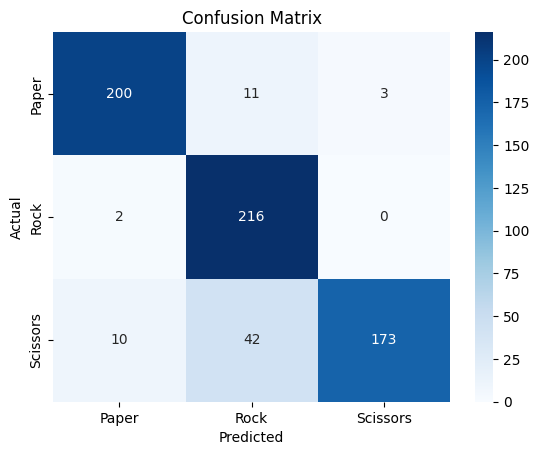

              precision    recall  f1-score   support

       Paper       0.94      0.93      0.94       214
        Rock       0.80      0.99      0.89       218
    Scissors       0.98      0.77      0.86       225

    accuracy                           0.90       657
   macro avg       0.91      0.90      0.90       657
weighted avg       0.91      0.90      0.90       657



In [67]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Paper','Rock','Scissors'],
            yticklabels=['Paper','Rock','Scissors'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred_classes,
                             target_names=['Paper','Rock','Scissors']))

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


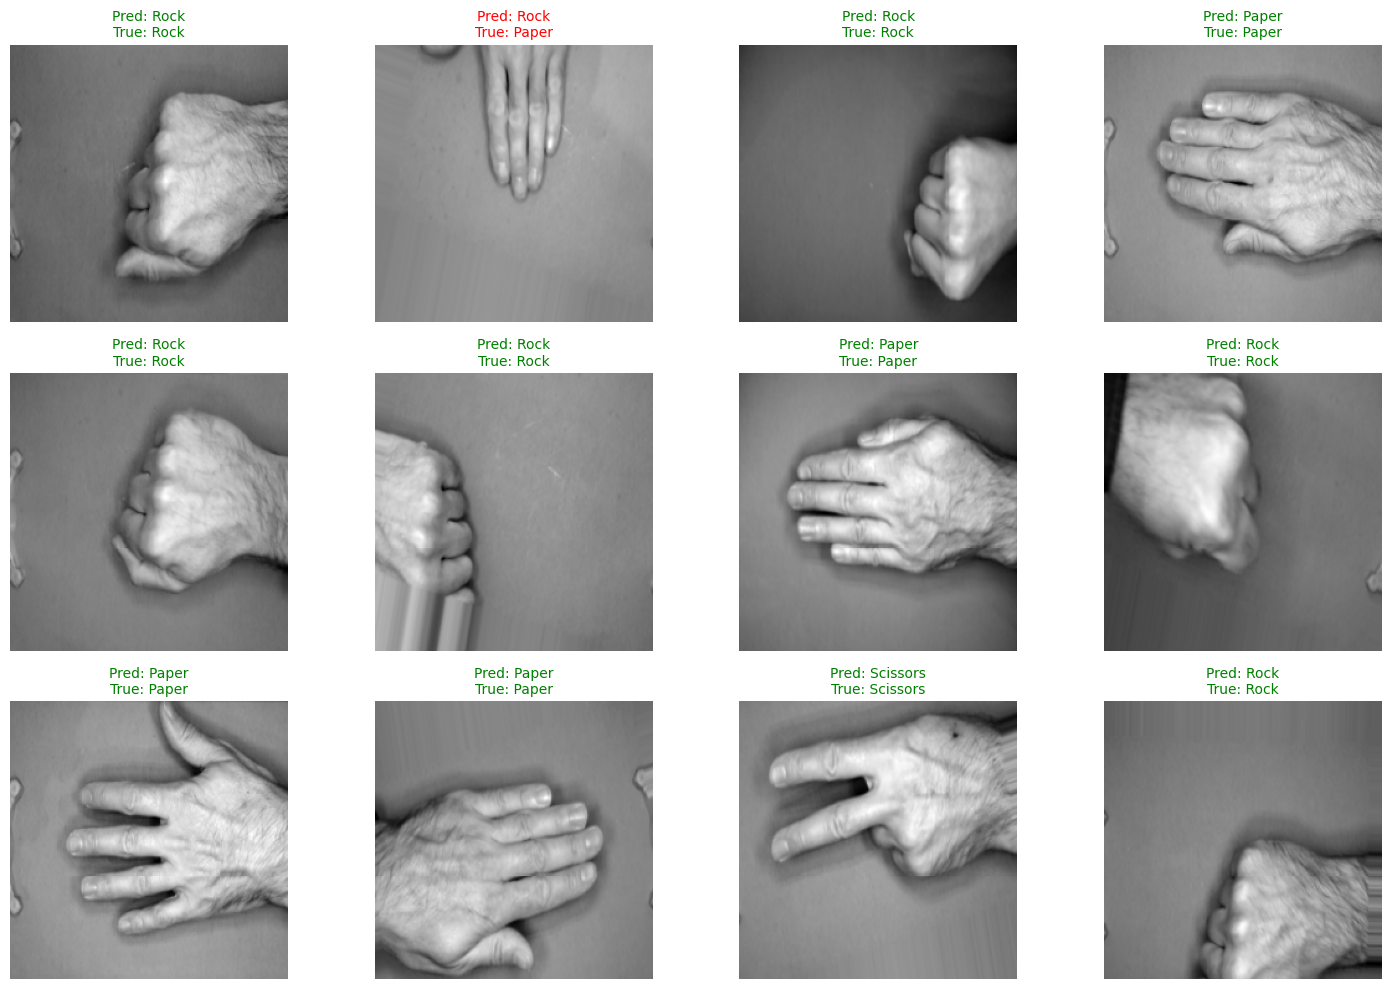

In [68]:
import matplotlib.pyplot as plt
import numpy as np

class_names = ['Paper', 'Rock', 'Scissors']

# Get predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Pick a random sample of images to display
num_images = 12
indices = np.random.choice(len(X_test), num_images, replace=False)

plt.figure(figsize=(15, 10))

for i, idx in enumerate(indices):
    plt.subplot(3, 4, i + 1)

    # Since images are grayscale with shape (224,224,1), squeeze to (224,224) for display
    img = X_test[idx].squeeze()
    plt.imshow(img, cmap='gray')

    pred_label = class_names[y_pred_classes[idx]]
    true_label = class_names[y_test[idx]]

    # Green title if correct, red if wrong
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()